### Análisis de los modelos

Librerías y modulos necesarios

In [1]:
import pandas as pd
# Librerías
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression

# Módulos
from funciones import *

CONSTANTES

In [2]:
# Id de los datos procesados en formato parquet, almacenados en drive
ID_DATOS = '1N9ucOBFVTi1A-LOU1UyqmU_-pUwR40SY'

In [3]:
# Se cargan los datos
data = cargar_parquet_drive(ID_DATOS)
data

,Marca,Modelo,Precio(€),Adicional,Primera matriculación,Kilometraje(Km),Carburante,Transmisión,Potencia(Cv),Tracción,Cilindrada(Cc),Accidentado,Edad(Meses)
0,Peugeot,3008,17899,1.2 PureTech Allure,2019-12-27,54616,Gasolina,manual,130,delantera,1199,No,51
1,Renault,Captur,16999,1.3 TCe Intens,2020-10-27,32383,Gasolina,manual,131,delantera,1332,No,41
2,BMW,Serie 2,14799,218d,2014-12-29,117846,Diésel,manual,143,trasera,1995,No,112
3,Fiat,500X,13499,1.6 E-Torq City Cross,2018-07-17,50914,Gasolina,manual,110,delantera,1598,No,69
4,BMW,Serie 1,16799,116i M Sport,2018-06-27,66438,Gasolina,manual,110,trasera,1499,No,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,Dacia,Duster,8099,1.6 Ambiance 4x2,2011-06-30,78287,Gasolina,manual,105,delantera,1598,No,154
1806,Volkswagen,Golf VII,26570,2.0 TSI GTI Performance BlueMotion,2018-05-17,67529,Gasolina,automatico,245,delantera,1984,No,71
1807,BMW,X4,29799,xDrive 20d,2017-12-11,96327,Diésel,automatico,190,total (4x4),1995,No,76
1808,Dacia,Sandero,9099,0.9 TCe Stepway,2015-11-04,93196,Gasolina,manual,90,delantera,898,No,101


## Registros nuevos

In [4]:
data_nuevos = pd.read_parquet("../limpieza/datosProcesados2.parquet")
merged_df = pd.merge(data, data_nuevos, left_index=True, right_index=True, how='outer', indicator=True, suffixes=('_x', ''))

# Filtrar solo las filas donde el indicador '_merge' sea 'left_only' (es decir, registros solo en df_nuevos)
registros_nuevos = merged_df[merged_df['_merge'] == 'right_only']

# Seleccionar solo las columnas sin el sufijo '_y'
registros_nuevos = registros_nuevos[[col for col in registros_nuevos.columns if not col.endswith('_x')]]

# Descartar la columna de indicador '_merge' si no es necesaria
registros_nuevos = registros_nuevos.drop(columns=['_merge'])

In [5]:
registros_nuevos

,Marca,Modelo,Precio(€),Adicional,Primera matriculación,Kilometraje(Km),Carburante,Transmisión,Potencia(Cv),Tracción,Cilindrada(Cc),Accidentado,Edad(Meses)
1810,Skoda,Karoq,21237,1.5 TSI ACT SportLine,2020-10-30,79151,Gasolina,automatico,150,delantera,1498,No,42
1811,BMW,X1,18599,sDrive 18d,2016-05-26,102292,Diésel,automatico,150,delantera,1995,No,96
1812,Opel,Mokka X,11999,1.6 CDTI Selective,2017-08-01,111070,Diésel,manual,135,delantera,1598,No,82
1813,Peugeot,508,12799,2.0 Blue-HDi Allure,2015-07-27,102822,Diésel,manual,150,delantera,1997,No,106
1814,Citroen,C4 Grand Picasso,12899,1.6 Blue-HDi Seduction 7 Plazas,2016-02-04,90350,Diésel,manual,120,delantera,1560,No,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867,Mercedes-Benz,Clase A,17999,A 180 CDI BlueEfficiency AMG Sport,2015-08-05,92894,Diésel,automatico,110,delantera,1461,No,106
1868,Seat,León,14499,2.0 TDI FR,2015-03-18,124450,Diésel,manual,150,delantera,1968,No,111
1869,Seat,Ateca,22899,1.5 TSI ACT FR,2020-10-26,46622,Gasolina,automatico,150,delantera,1498,No,42
1870,Fiat,500,10099,1.2 S,2017-11-06,45951,Gasolina,manual,70,delantera,1242,No,79


In [10]:
registros_nuevos.to_parquet("datosNuevos.parquet", index=0)

In [ ]:
# Análisis estadístico descriptivo
print("Estadísticas descriptivas de las características:")
print(data.describe())

# Visualización de la correlación
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r',center=0)
plt.title('Matriz de correlación de características')
plt.show()

In [50]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
data.rename(columns={'Precio(€)': 'Precio'}, inplace=True)


# ANOVA para Carburante
model_carburante = ols('Precio ~ C(Carburante)', data=data).fit()
anova_table_carburante = sm.stats.anova_lm(model_carburante, typ=2)
print("ANOVA para Carburante:")
print(anova_table_carburante)

ANOVA para Carburante:
                     sum_sq      df          F        PR(>F)
C(Carburante)  6.536875e+09     3.0  61.824537  4.773689e-38
Residual       6.365108e+10  1806.0        NaN           NaN


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Carburante', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Carburante')
plt.xlabel('Tipo de Carburante')
plt.ylabel('Precio')
plt.show()

In [52]:
# ANOVA para Tracción
model_traccion = ols('Precio ~ C(Tracción)', data=data).fit()
anova_table_traccion = sm.stats.anova_lm(model_traccion, typ=2)
print("ANOVA para Tracción:")
print(anova_table_traccion)

ANOVA para Tracción:
                   sum_sq      df           F        PR(>F)
C(Tracción)  8.864102e+09     2.0  130.656415  1.018879e-53
Residual     6.119424e+10  1804.0         NaN           NaN


In [ ]:
# Crear un boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tracción', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Tracción')
plt.xlabel('Tipo de Tracción')
plt.ylabel('Precio')
plt.show()

In [54]:
# ANOVA para Transmisión
model_transmision = ols('Precio ~ C(Transmisión)', data=data).fit()
anova_table_transmision = sm.stats.anova_lm(model_transmision, typ=2)
print("ANOVA para Transmisión:")
print(anova_table_transmision)

ANOVA para Transmisión:
                      sum_sq      df           F         PR(>F)
C(Transmisión)  2.064595e+10     1.0  753.458942  5.931840e-139
Residual        4.954201e+10  1808.0         NaN            NaN


In [ ]:
# Crear un boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmisión', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Transmisión')
plt.xlabel('Tipo de Transmisión')
plt.ylabel('Precio')
plt.show()

In [ ]:
# ANOVA para Marca
model_Marca = ols('Precio ~ C(Marca)', data=data).fit()
anova_table_Marca = sm.stats.anova_lm(model_Marca, typ=2)
print("ANOVA para Marca:")
print(anova_table_Marca)

In [ ]:
# Crear un boxplot
plt.figure(figsize=(50, 50))
sns.boxplot(x='Marca', y='Precio', data=data)
plt.title('Distribución de Precios por Tipo de Marca')
plt.xlabel('Marcas')
plt.ylabel('Precio')
plt.show()

In [58]:
# ANOVA para Modelo
model_Modelo = ols('Precio ~ C(Modelo)', data=data).fit()
anova_table_Modelo = sm.stats.anova_lm(model_Modelo, typ=2)
print("ANOVA para Modelo:")
print(anova_table_Modelo)

ANOVA para Modelo:
                 sum_sq      df          F         PR(>F)
C(Modelo)  4.821235e+10   254.0  13.431177  2.950333e-256
Residual   2.197561e+10  1555.0        NaN            NaN


In [4]:
# Separación entre variables de entrada y objetivo
X = data.drop(columns=["Precio(€)", "Accidentado", "Adicional", "Primera matriculación"])
y = data["Precio(€)"]
# En la memoria explicamos el porqué no usamos las variables "Accidentado", "Adicional" y "Primera matriculación"

# Ahora aplicamos las transformaciones necesarias
X, encoder = transformData(X)

# Con los datos ya listos, separamos entre train y test
X_train, X_test, y_train, y_test = splitTrainTest(X, y)

In [5]:
X

,Kilometraje(Km),Potencia(Cv),Cilindrada(Cc),Edad(Meses),Marca_Abarth,Marca_Alfa,Marca_Audi,Marca_BMW,Marca_Chevrolet,Marca_Citroen,...,Modelo_up!,Carburante_Diésel,Carburante_GLP,Carburante_Gasolina,Carburante_Híbrido,Transmisión_ manual,Tracción_delantera,Tracción_total (4x4),Tracción_trasera,Tracción_None
0,-0.398419,0.257450,-0.692719,-0.739454,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
1,-0.982373,0.285582,-0.321215,-1.062359,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,1.262327,0.623170,1.530721,1.230270,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.495653,-0.305197,0.421794,-0.158224,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
4,-0.087912,-0.305197,0.145261,-0.158224,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,0.223304,-0.445859,0.421794,2.586474,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
1806,-0.059257,3.492668,1.499995,-0.093643,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1807,0.697127,1.945390,1.530721,0.067810,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1808,0.614891,-0.867844,-1.533493,0.875074,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [60]:
# ANÁLISIS DE VARIABLES DE JESUS

Generamos los modelos con los hiperparámetros óptimos para cada modelo

In [6]:
# Modelo de RedesNeuronales
mlp = MLPRegressor(hidden_layer_sizes=(150, 100), alpha=0.001, activation='relu', random_state=42, max_iter=1000)
mlp.fit(X_train, y_train.ravel())

C:\Users\bryan\AppData\Local\Temp\ipykernel_24872\1671567403.py:3: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  mlp.fit(X_train, y_train.ravel())
C:\Users\bryan\PycharmProjects\proyectoDatos\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(alpha=0.001, hidden_layer_sizes=(150, 100), max_iter=1000,
             random_state=42)

In [61]:
# Modelo de RedesNeuronales
mlp = MLPRegressor(hidden_layer_sizes=(150, 100), alpha=0.001, activation='relu', random_state=42, max_iter=1000)
mlp.fit(X_train, y_train.ravel())

# Modelo de RandomForest
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train, y_train.ravel())

# Modelo de Regresión lineal
rl = LinearRegression(fit_intercept = True, copy_X = False)
rl.fit(X_train, y_train.ravel())

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


LinearRegression(copy_X=False)

Obtenemos los resultados y graficamos

In [6]:
def desplegarResultado(modelo, X_test, y_test, nombre_modelo):
    precisionTest = modelo.score(X_test, y_test.ravel())
    print(f"Precisión del modelo {nombre_modelo} (R^2):", precisionTest)
    # Evaluamos el modelo en el conjunto de prueba
    y_pred = modelo.predict(X_test)
    analisisResultado(y_test, y_pred)
    plotModelo(y_test, y_pred, nombre_modelo)

In [10]:
X_test

,Kilometraje(Km),Potencia(Cv),Cilindrada(Cc),Edad(Meses),Marca_Abarth,Marca_Alfa,Marca_Audi,Marca_BMW,Marca_Chevrolet,Marca_Citroen,...,Modelo_up!,Carburante_Diésel,Carburante_GLP,Carburante_Gasolina,Carburante_Híbrido,Transmisión_ manual,Tracción_delantera,Tracción_total (4x4),Tracción_trasera,Tracción_None
1370,-0.445828,0.820096,1.530721,-0.481129,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
65,-1.234912,0.116788,0.120121,-1.126941,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1289,-0.613715,-1.092902,-0.692719,-0.255095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
941,0.228714,-0.108271,0.399448,0.164682,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
1067,-0.533764,-1.346093,-1.251373,-0.416548,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,0.691848,-1.289829,-0.913388,0.455297,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
963,0.480860,-0.305197,0.039117,-0.158224,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
677,0.034693,0.398111,1.499995,1.230270,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
118,-0.619546,-0.164535,-1.251373,-0.255095,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


C:\Users\bryan\AppData\Local\Temp\ipykernel_24872\824703488.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  precisionTest = modelo.score(X_test, y_test.ravel())


Precisión del modelo Redes Neuronales (R^2): 0.892743731735459

MAE:  1254.7385630232118


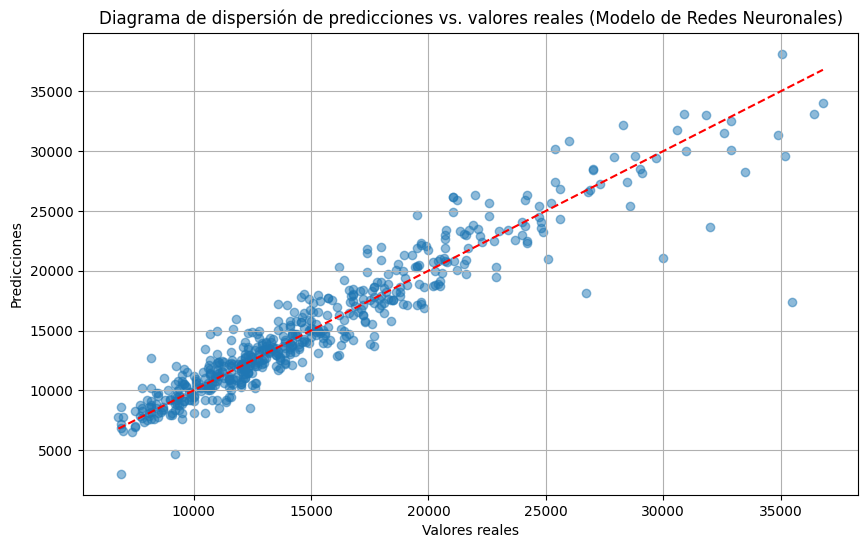

In [9]:
desplegarResultado(mlp, X_test, y_test, "Redes Neuronales")
print('\n\n')

Precisión del modelo Redes Neuronales (R^2): 0.892743731735459

MAE:  1254.7385630232118


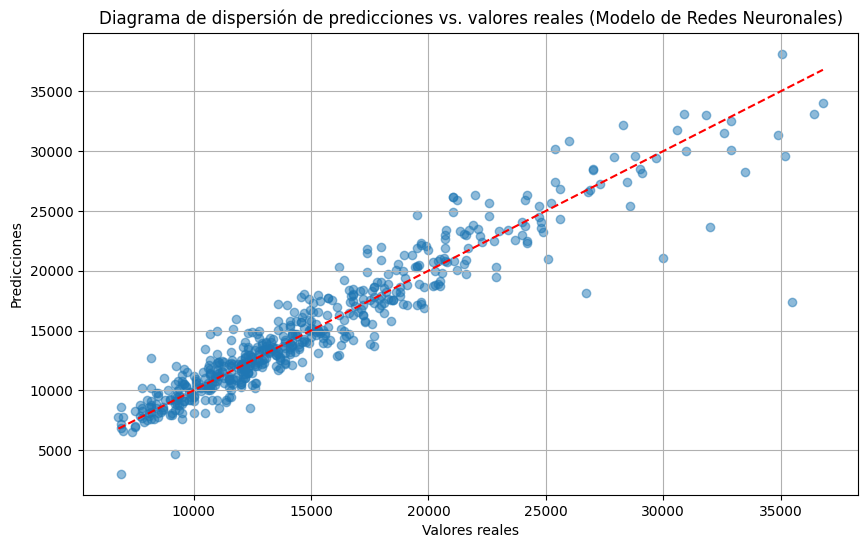




Precisión del modelo Random Forest (R^2): 0.8358412538230723

MAE:  1598.9573774300636


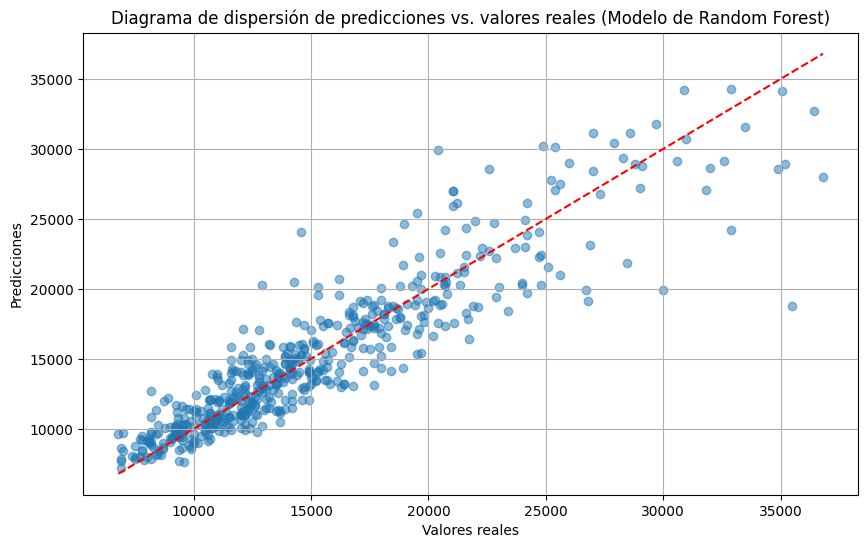




Precisión del modelo Linear Regression (R^2): -1.8743896082177553e+20

MAE:  11463957692327.244


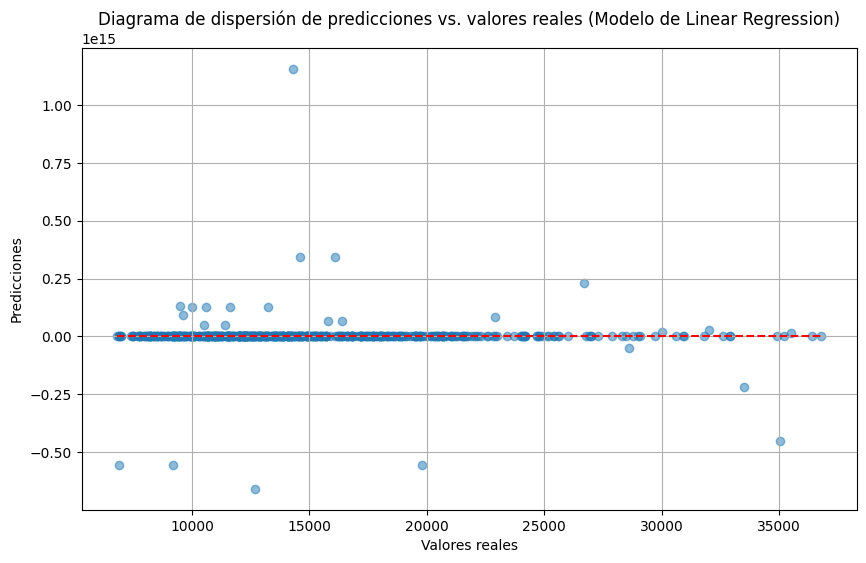

In [63]:
desplegarResultado(mlp, X_test, y_test, "Redes Neuronales")
print('\n\n')
desplegarResultado(rfr, X_test, y_test, "Random Forest")
print('\n\n')
desplegarResultado(rl, X_test, y_test, "Linear Regression")

## Analisís con registros nuevos

In [7]:
registros_nuevos = pd.read_parquet("datosNuevos.parquet")

In [8]:
registros_nuevos

,Marca,Modelo,Precio(€),Adicional,Primera matriculación,Kilometraje(Km),Carburante,Transmisión,Potencia(Cv),Tracción,Cilindrada(Cc),Accidentado,Edad(Meses)
1810,Skoda,Karoq,21237,1.5 TSI ACT SportLine,2020-10-30,79151,Gasolina,automatico,150,delantera,1498,No,42
1811,BMW,X1,18599,sDrive 18d,2016-05-26,102292,Diésel,automatico,150,delantera,1995,No,96
1812,Opel,Mokka X,11999,1.6 CDTI Selective,2017-08-01,111070,Diésel,manual,135,delantera,1598,No,82
1813,Peugeot,508,12799,2.0 Blue-HDi Allure,2015-07-27,102822,Diésel,manual,150,delantera,1997,No,106
1814,Citroen,C4 Grand Picasso,12899,1.6 Blue-HDi Seduction 7 Plazas,2016-02-04,90350,Diésel,manual,120,delantera,1560,No,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867,Mercedes-Benz,Clase A,17999,A 180 CDI BlueEfficiency AMG Sport,2015-08-05,92894,Diésel,automatico,110,delantera,1461,No,106
1868,Seat,León,14499,2.0 TDI FR,2015-03-18,124450,Diésel,manual,150,delantera,1968,No,111
1869,Seat,Ateca,22899,1.5 TSI ACT FR,2020-10-26,46622,Gasolina,automatico,150,delantera,1498,No,42
1870,Fiat,500,10099,1.2 S,2017-11-06,45951,Gasolina,manual,70,delantera,1242,No,79


In [11]:
def transformData2(datos, encoder):
    # Aplicamos OneHotEncoder a las variables categóricas (las de tipo string)
    toEncode = ["Marca", "Modelo", "Carburante", "Transmisión", "Tracción"]
    datosCat = datos[toEncode]
    features = encoder.get_feature_names_out()
    datosCat = pd.DataFrame(encoder.transform(datosCat), columns=features)
    dataTrans = pd.concat([datos.drop(columns=toEncode), datosCat], axis=1)

    # También estandarizamos estos valores numéricos
    estandarizar = ["Kilometraje(Km)", "Potencia(Cv)", "Cilindrada(Cc)", "Edad(Meses)"]
    scaler = StandardScaler()
    dataTrans[estandarizar] = scaler.fit_transform(dataTrans[estandarizar])
    return dataTrans


In [15]:
# Modelo de RedesNeuronales
mlpNuevos = MLPRegressor(hidden_layer_sizes=(150, 100), alpha=0.001, activation='relu', random_state=42, max_iter=1000)
mlpNuevos.fit(X, y.ravel())

C:\Users\bryan\AppData\Local\Temp\ipykernel_18556\2730712121.py:3: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  mlpNuevos.fit(X, y.ravel())
C:\Users\bryan\PycharmProjects\proyectoDatos\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(alpha=0.001, hidden_layer_sizes=(150, 100), max_iter=1000,
             random_state=42)

In [9]:
# Separación entre variables de entrada y objetivo
X_nuevos = registros_nuevos.drop(columns=["Precio(€)", "Accidentado", "Adicional", "Primera matriculación"])
y_nuevos = registros_nuevos["Precio(€)"]
X_nuevos.reset_index(drop=True, inplace=True)

In [12]:
X_nuevos = transformData2(X_nuevos, encoder)
y_nuevos = y_nuevos.to_numpy()

Precisión del modelo Redes Neuronales (R^2): 0.9372924066792645

MAE:  1210.9286657354235


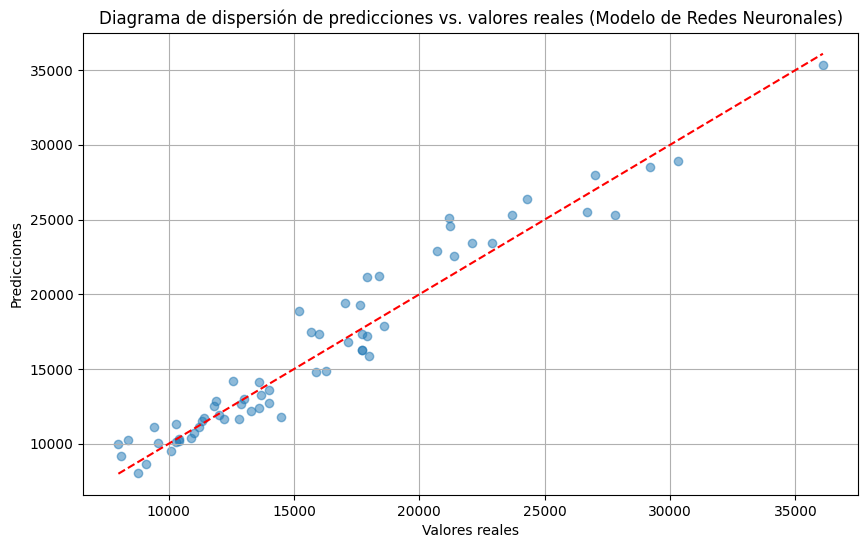

In [16]:
desplegarResultado(mlpNuevos, X_nuevos, y_nuevos, "Redes Neuronales")